# SAS vs HAR — Failure Analysis

This notebook dissects where and why SAS_q2 underperforms HAR.

**Structure**
1. Setup — load OOS errors, align series
2. Full OOS overview — predictions + rolling loss ratios
3. Failure zoom — auto-detect worst 100-step windows, plot 200 steps around each
4. QLIKE spike anatomy — when and how large are the blowups?
5. Volatility transition analysis — does SAS fail at low→high vol transitions?
6. Calibration scatter — systematic prediction bias


## 1 · Setup

In [ ]:
# Set to True when main.py was run with --log (log-RV mode).
# In log-RV mode QLIKE is computed with the log-space formula:
#   QLIKE_log = exp(ŷ)/exp(y) − (y − ŷ) − 1
# which equals standard level QLIKE applied to exp(·) — still meaningful.
LOG = False

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 9,
})

# ── parameters ────────────────────────────────────────────────────────────────
ROOT      = Path('..').resolve()
SYMBOL    = '.SPX'          # change to any symbol in results/
BENCH     = 'HAR'
CHALLENGER= 'SAS_q2'        # or SAS_q1, NLinear, …
H         = 1               # horizon to analyse
ROLL_W    = 100             # rolling window for cumulative losses
ZOOM_HALF = 100             # ±steps plotted around each failure centre
N_PEAKS   = 4               # number of non-overlapping failure windows

# ── load ─────────────────────────────────────────────────────────────────────
fname = ROOT / 'results' / f"errors_{SYMBOL.lstrip('.')}.csv"
df_all = pd.read_csv(fname, parse_dates=['test_date'])
df_h   = df_all[df_all['horizon'] == H].sort_values('test_date')

bench = df_h[df_h['config'] == BENCH      ].set_index('test_date')
chal  = df_h[df_h['config'] == CHALLENGER ].set_index('test_date')
dates = bench.index.intersection(chal.index).sort_values()
bench, chal = bench.loc[dates], chal.loc[dates]

y_true   = bench['y_true'].values
y_bench  = bench['y_pred'].values
y_chal   = chal['y_pred'].values
sq_bench = bench['sq_err'].values
sq_chal  = chal['sq_err'].values
ql_bench = bench['qlike'].values
ql_chal  = chal['qlike'].values

_qlike_label = "log-space QLIKE" if LOG else "QLIKE"
print(f"Symbol : {SYMBOL}  |  Horizon h={H}  |  {len(dates)} OOS steps  |  log-RV={LOG}")
print(f"Period : {dates[0].date()} → {dates[-1].date()}")
print(f"Mean sq_err  — {BENCH}: {sq_bench.mean():.2e}   {CHALLENGER}: {sq_chal.mean():.2e}")
print(f"Mean {_qlike_label}  — {BENCH}: {np.nanmean(ql_bench):.4f}   {CHALLENGER}: {np.nanmean(ql_chal):.4f}")

## 2 · Full OOS Overview

Top panel: true RV vs both predictions.  
Middle: rolling MSE ratio (challenger / benchmark) — red = challenger worse.  
Bottom: rolling QLIKE ratio (log-scaled) — captures tail blowups.

In [ ]:
from scipy.ndimage import gaussian_filter1d

GAUSS_SIGMA = 1

def gsmooth(arr):
    """Apply Gaussian filter ignoring NaNs: interpolate → filter → restore NaNs."""
    a   = arr.copy().astype(float)
    nan = ~np.isfinite(a)
    a[nan] = np.interp(np.where(nan)[0], np.where(~nan)[0], a[~nan])
    out = gaussian_filter1d(a, sigma=GAUSS_SIGMA)
    out[nan] = np.nan
    return out

sq_bench_s = pd.Series(sq_bench, index=dates)
sq_chal_s  = pd.Series(sq_chal,  index=dates)

smooth_sq_bench = gsmooth(sq_bench)
smooth_sq_chal  = gsmooth(sq_chal)

ratio_mse = np.where(smooth_sq_bench > 1e-30,
                     smooth_sq_chal / smooth_sq_bench, np.nan)

smooth_ql_bench = gsmooth(np.where(np.isfinite(ql_bench), ql_bench, np.nan))
smooth_ql_chal  = gsmooth(np.where(np.isfinite(ql_chal),  ql_chal,  np.nan))
diff_ql = smooth_ql_chal - smooth_ql_bench

_qlike_label = "log-space QLIKE" if LOG else "QLIKE"

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1, 1]})
fig.suptitle(
    f"{SYMBOL} · h={H} · {CHALLENGER} vs {BENCH} — full OOS  "
    f"(Gaussian-smoothed, σ={GAUSS_SIGMA} steps)"
    + (f"  [log-RV: {_qlike_label}]" if LOG else ""),
    fontsize=11
)

# ── panel 1: raw predictions + Gaussian-smoothed predictions ──────────────────
ax = axes[0]
ax.plot(dates, y_true,  color='black',     lw=0.55, alpha=0.55, label='True RV (raw)')
ax.plot(dates, y_bench, color='steelblue', lw=0.55, alpha=0.45)
ax.plot(dates, y_chal,  color='tomato',    lw=0.55, alpha=0.45)
ax.plot(dates, gsmooth(y_true),  color='black',     lw=1.4, alpha=0.95, label='True RV (smooth)')
ax.plot(dates, gsmooth(y_bench), color='steelblue', lw=1.4, alpha=0.9,  label=f'{BENCH} (smooth)')
ax.plot(dates, gsmooth(y_chal),  color='tomato',    lw=1.4, alpha=0.9,  label=f'{CHALLENGER} (smooth)')
ax.set_ylabel('log-RV' if LOG else 'RV')
ax.legend(loc='upper right', fontsize=8)

# ── panel 2: Gaussian-smoothed MSE ratio ──────────────────────────────────────
ax = axes[1]
ax.plot(dates, ratio_mse, color='purple', lw=1.1,
        label=f'Smoothed MSE ratio  {CHALLENGER}/{BENCH}  (σ={GAUSS_SIGMA})')
ax.axhline(1.0, color='gray', lw=0.8, ls='--')
ax.fill_between(dates, 1, ratio_mse,
                where=np.nan_to_num(ratio_mse) > 1, color='tomato',    alpha=0.25)
ax.fill_between(dates, 1, ratio_mse,
                where=np.nan_to_num(ratio_mse) < 1, color='steelblue', alpha=0.25)
ax.set_ylabel('MSE ratio')
ax.legend(fontsize=8, loc='upper right')

# ── panel 3: Gaussian-smoothed QLIKE diff ─────────────────────────────────────
ax = axes[2]
ax.plot(dates, diff_ql, color='darkorange', lw=1.1,
        label=f'Δ{_qlike_label}  {CHALLENGER}−{BENCH}  (σ={GAUSS_SIGMA})')
ax.axhline(0.0, color='gray', lw=0.8, ls='--')
ax.fill_between(dates, 0, diff_ql,
                where=np.nan_to_num(diff_ql) > 0, color='tomato',    alpha=0.25)
ax.fill_between(dates, 0, diff_ql,
                where=np.nan_to_num(diff_ql) < 0, color='steelblue', alpha=0.25)
ax.set_ylabel(f'Δ{_qlike_label}')
ax.set_xlabel('Date')
ax.legend(fontsize=8, loc='upper right')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('sas_overview.png', bbox_inches='tight')
plt.show()

## 3 · Failure Zoom Panels

4 windows — 2 by MSE ratio, 2 by cumulative QLIKE difference.

- **MSE** — rolling 100-step *MSE ratio* (challenger / benchmark): episodes where SAS is simply less accurate.
- **QLIKE** — rolling 100-step *cumulative QLIKE difference* (challenger − benchmark): tail-risk episodes where SAS severely underforecasts, measured in excess of HAR.
  When `LOG = True`, QLIKE uses the log-space formula `exp(ŷ−y) + (ŷ−y) − 1`, which is still meaningful and comparable across steps.

Peaks are non-overlapping (≥ `2 × ZOOM_HALF` apart).

In [ ]:
C_BENCH = 'steelblue'
C_CHAL  = 'tomato'
C_TRUE  = 'black'

# Always rebuild from the raw arrays loaded in cell-2 — never rely on stale
# kernel state from a previous run with a different symbol.
N          = len(dates)
s_sq_bench = pd.Series(sq_bench,                                   index=dates)
s_sq_chal  = pd.Series(sq_chal,                                    index=dates)
s_ql_bench = pd.Series(np.where(np.isfinite(ql_bench), ql_bench, np.nan),
                        index=dates)
s_ql_chal  = pd.Series(np.where(np.isfinite(ql_chal),  ql_chal,  np.nan),
                        index=dates)

def find_peaks_nonolap(score_arr, K, min_gap):
    """
    Greedily pick K non-overlapping argmax positions.
    inf values are replaced by finite max so nanargmax stays in bounds.
    All returned positions are hard-clipped to [0, len(score_arr)-1].
    """
    n = len(score_arr)
    s = score_arr.copy().astype(float)
    fin = s[np.isfinite(s)]
    if fin.size == 0:
        return []
    s[np.isposinf(s)] = fin.max()
    peaks = []
    for _ in range(K):
        if not np.any(np.isfinite(s) & (s > 0)):
            break
        pos = int(np.clip(np.nanargmax(s), 0, n - 1))
        peaks.append(pos)
        s[max(0, pos - min_gap): min(n, pos + min_gap)] = np.nan
    return peaks

MIN_GAP = 2 * ZOOM_HALF
_qlike_label = "log-space QLIKE" if LOG else "QLIKE"

# ── Score 1: rolling MSE ratio ────────────────────────────────────────────────
roll_bench = s_sq_bench.rolling(ROLL_W, min_periods=ROLL_W // 2).mean()
roll_chal  = s_sq_chal.rolling( ROLL_W, min_periods=ROLL_W // 2).mean()
mse_ratio_roll = np.where(
    roll_bench.values > 1e-30,
    roll_chal.values / roll_bench.values,
    np.nan
)

peaks_mse = find_peaks_nonolap(mse_ratio_roll, K=2, min_gap=MIN_GAP)

# ── Score 2: rolling cumulative QLIKE difference (challenger − benchmark) ──────
# QLIKE difference measures excess tail-risk of the challenger vs the benchmark.
# Valid for both level-space and log-space QLIKE (both computed by run_oos).
cumul_ql_diff = (s_ql_chal - s_ql_bench).rolling(ROLL_W, min_periods=ROLL_W // 2).sum().values

peaks_qlik = find_peaks_nonolap(cumul_ql_diff, K=2, min_gap=MIN_GAP)

# De-duplicate: drop QLIKE peaks inside an MSE peak's exclusion zone
peaks_qlik_clean = [p for p in peaks_qlik
                    if all(abs(p - m) >= MIN_GAP for m in peaks_mse)]
if len(peaks_qlik_clean) < 2:
    s_retry = cumul_ql_diff.copy().astype(float)
    for m in peaks_mse + peaks_qlik_clean:
        s_retry[max(0, m - MIN_GAP): min(N, m + MIN_GAP)] = np.nan
    peaks_qlik_clean += find_peaks_nonolap(
        s_retry, K=2 - len(peaks_qlik_clean), min_gap=MIN_GAP
    )

all_peaks = (
    [(p, 'MSE failure')   for p in peaks_mse] +
    [(p, 'QLIKE failure') for p in peaks_qlik_clean[:2]]
)
all_peaks.sort(key=lambda x: x[0])

# ── summary ───────────────────────────────────────────────────────────────────
print(f"{'Source':<16}  {'Window end':^12}  {'Window centre':^14}  Score")
print("─" * 65)
for pos, label in all_peaks:
    pos    = int(np.clip(pos, 0, N - 1))
    centre = int(np.clip(pos - ROLL_W // 2, 0, N - 1))
    score  = (f"MSE ratio       = {mse_ratio_roll[pos]:.3f}" if 'MSE' in label
              else f"cumul Δ{_qlike_label} = {cumul_ql_diff[pos]:.2f}")
    print(f"{label:<16}  {str(dates[pos].date()):^12}  "
          f"{str(dates[centre].date()):^14}  {score}")

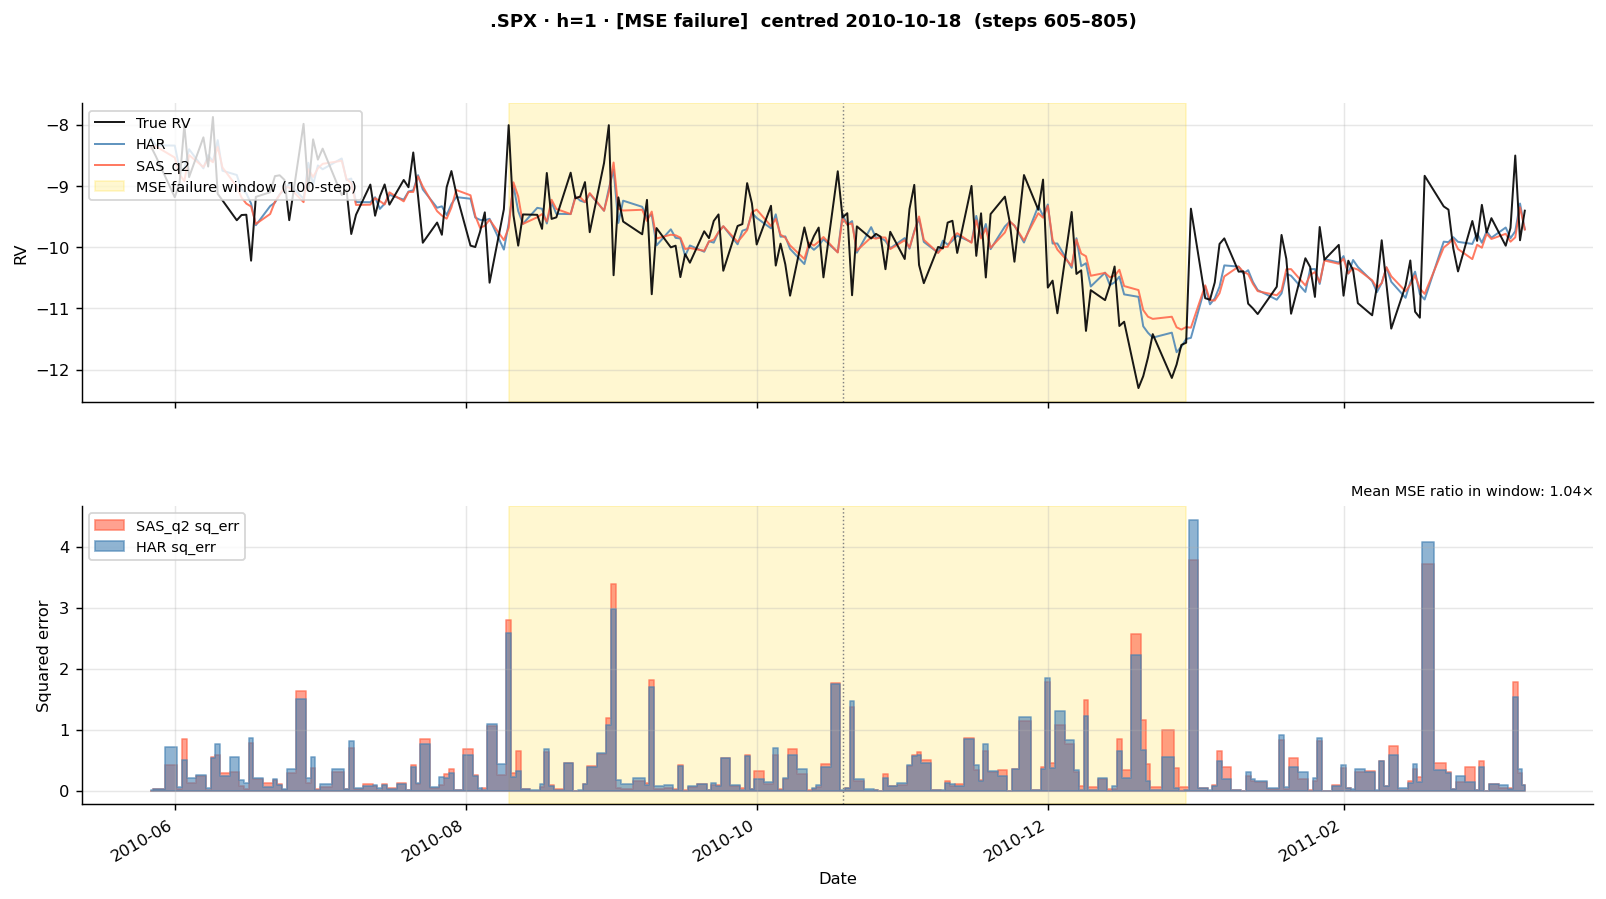

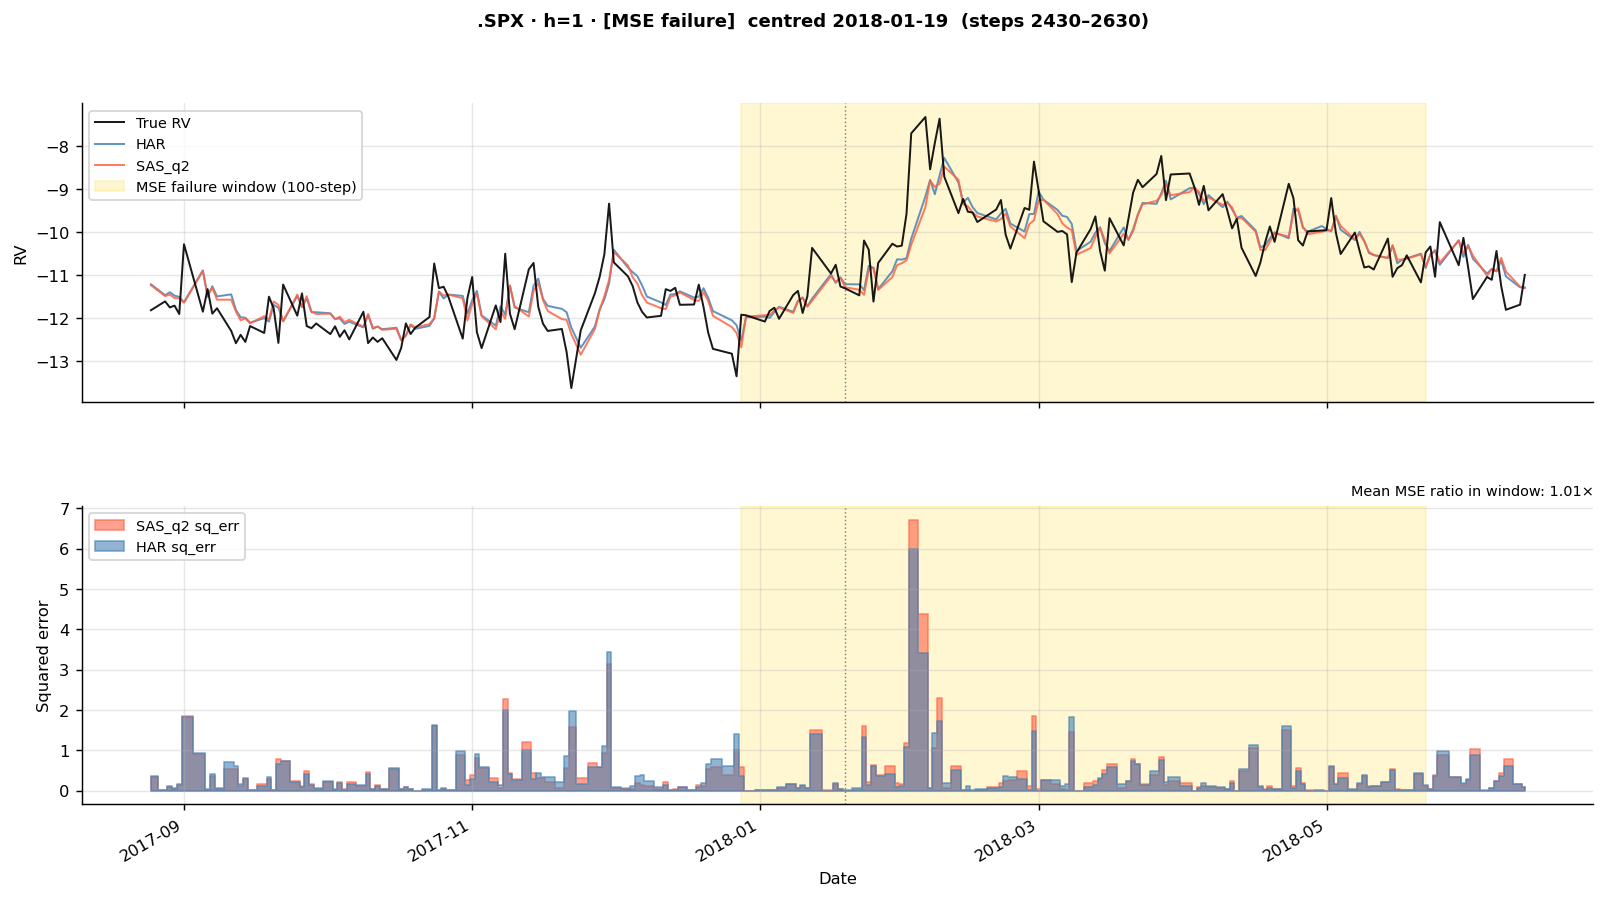

In [41]:
SHADE = {'MSE failure':   ('gold',   'MSE failure window (100-step)'),
         'QLIKE failure': ('orchid', 'QLIKE failure window (100-step)')}

for peak_pos, peak_label in all_peaks:
    peak_pos = int(np.clip(peak_pos, 0, N - 1))
    is_mse   = 'MSE' in peak_label

    # Rolling window at t covers [t - ROLL_W + 1, t].
    # Peak = end of worst window → centre = peak - ROLL_W // 2.
    centre = int(np.clip(peak_pos - ROLL_W // 2, ZOOM_HALF, N - 1 - ZOOM_HALF))
    lo, hi = centre - ZOOM_HALF, centre + ZOOM_HALF
    sl, d  = slice(lo, hi), dates[lo:hi]

    win_lo = dates[max(0, peak_pos - ROLL_W + 1)]
    win_hi = dates[min(N - 1, peak_pos)]
    shade_color, shade_lbl = SHADE[peak_label]

    fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                              gridspec_kw={'hspace': 0.35})
    fig.suptitle(
        f"{SYMBOL} · h={H} · [{peak_label}]  centred {dates[centre].date()}"
        f"  (steps {lo}–{hi})",
        fontsize=10, fontweight='bold'
    )

    # ── panel 1: RV + predictions ─────────────────────────────────────
    ax1 = axes[0]
    ax1.plot(d, y_true[sl],  color=C_TRUE,  lw=1.1, label='True RV',  alpha=0.9,  zorder=3)
    ax1.plot(d, y_bench[sl], color=C_BENCH, lw=1.1, label=BENCH,       alpha=0.85, zorder=2)
    ax1.plot(d, y_chal[sl],  color=C_CHAL,  lw=1.1, label=CHALLENGER,  alpha=0.85, zorder=2)
    ax1.axvspan(win_lo, win_hi, color=shade_color, alpha=0.18, label=shade_lbl, zorder=1)
    ax1.axvline(dates[centre], color='gray', lw=0.8, ls=':')
    ax1.set_ylabel('RV')
    ax1.legend(loc='upper left', fontsize=8)

    # ── panel 2: metric specific to failure type ──────────────────────
    ax2 = axes[1]
    ax2.axvspan(win_lo, win_hi, color=shade_color, alpha=0.18, zorder=1)
    ax2.axvline(dates[centre], color='gray', lw=0.8, ls=':')

    if is_mse:
        ax2.fill_between(d, sq_chal[sl],  step='mid',
                         color=C_CHAL,  alpha=0.6, label=f'{CHALLENGER} sq_err')
        ax2.fill_between(d, sq_bench[sl], step='mid',
                         color=C_BENCH, alpha=0.6, label=f'{BENCH} sq_err')
        ax2.set_ylabel('Squared error')
        ratio_annot = np.nanmean(sq_chal[lo:peak_pos]) / max(
            np.nanmean(sq_bench[lo:peak_pos]), 1e-30)
        ax2.set_title(f"Mean MSE ratio in window: {ratio_annot:.2f}×",
                      fontsize=8, loc='right')
    else:
        ql_c = np.where(np.isfinite(ql_chal[sl]),  ql_chal[sl],  np.nan)
        ql_b = np.where(np.isfinite(ql_bench[sl]), ql_bench[sl], np.nan)
        ax2.fill_between(d, ql_c, step='mid',
                         color=C_CHAL,  alpha=0.6, label=f'{CHALLENGER} QLIKE')
        ax2.fill_between(d, ql_b, step='mid',
                         color=C_BENCH, alpha=0.6, label=f'{BENCH} QLIKE')
        ax2.set_ylabel('QLIKE absolute')
        ax2.set_title(f"Mean {CHALLENGER} QLIKE in window: {np.nanmean(ql_c):.2f}",
                      fontsize=8, loc='right')

    ax2.legend(loc='upper left', fontsize=8)
    ax2.set_xlabel('Date')

    for ax in (ax1, ax2):
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    safe = f"{peak_label.replace(' ', '_')}_{dates[centre].date()}"
    plt.savefig(f'failure_zoom_{safe}.png', bbox_inches='tight')
    plt.show()

## 4 · QLIKE Spike Anatomy

Plot every individual QLIKE value over time (log scale).  
The *ratio* panel below shows when SAS blows up relative to HAR — a spike here means SAS predicted near-zero on a high-RV day (level) or a large forecast error in log space.  
Annotate the worst 10 events.

In [ ]:
_qlike_label = "log-space QLIKE" if LOG else "QLIKE"

# Identify the top-10 worst single-step QLIKE events for the challenger (absolute)
ql_chal_s_indexed = pd.Series(
    np.where(np.isfinite(ql_chal), ql_chal, np.nan), index=dates
)
top_events = ql_chal_s_indexed.nlargest(10)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle(
    f"{SYMBOL} · h={H} · {CHALLENGER} {_qlike_label} — spike anatomy\n"
    f"(top-10 worst steps annotated)",
    fontsize=11
)

# ── panel 1: raw QLIKE series for both models (log scale) ──
ax = axes[0]
ax.semilogy(dates, ql_chal,  color=C_CHAL,  lw=0.65, alpha=0.85, label=f'{CHALLENGER} {_qlike_label}')
ax.semilogy(dates, ql_bench, color=C_BENCH, lw=0.65, alpha=0.85, label=f'{BENCH} {_qlike_label}')
for t, ql_v in top_events.items():
    if np.isfinite(ql_v):
        ax.annotate(
            t.strftime('%Y-%m-%d'),
            xy=(t, ql_v),
            xytext=(4, 4), textcoords='offset points',
            fontsize=6, color='darkred',
            arrowprops=dict(arrowstyle='-', lw=0.4, color='darkred'),
        )
ax.set_ylabel(f'{_qlike_label} (log scale)')
ax.legend(fontsize=8, loc='upper right')

# ── panel 2: true RV (fill) with spike dates marked ──
ax = axes[1]
ax.fill_between(dates, 0, y_true, color='black', alpha=0.3, label='True RV')
for t in top_events.index:
    ax.axvline(t, color='darkred', lw=0.8, ls='--', alpha=0.75)
ax.set_ylabel('log-RV' if LOG else 'True RV')
ax.set_xlabel('Date')
ax.legend(fontsize=8)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('qlike_spikes.png', bbox_inches='tight')
plt.show()

print(f"\nTop-10 single-step {CHALLENGER} {_qlike_label} events:")
print(f"{'Date':<14}  {'QLIKE_chal':>12}  {'QLIKE_bench':>12}  "
      f"{'true_rv':>10}  {'chal_pred':>10}  {'bench_pred':>10}")
print("─" * 75)
for t, ql_v in top_events.items():
    idx = dates.get_loc(t)
    print(f"{str(t.date()):<14}  {ql_v:>12.2f}  "
          f"{ql_bench[idx]:>12.4f}  "
          f"{y_true[idx]:>10.2e}  {y_chal[idx]:>10.2e}  {y_bench[idx]:>10.2e}")

## 5 · Volatility Transition Analysis

Hypothesis: SAS fails specifically when realised volatility **jumps** — i.e., after a low-vol period the reservoir state has adapted to low levels and is too slow to react.

**Method**: compute, at each step, the "vol jump ratio" = RV_t / median(RV_{t-20:t-1}).  
Then compare the distribution of this ratio at failure steps vs normal steps.

ValueError: `bins` must increase monotonically, when an array

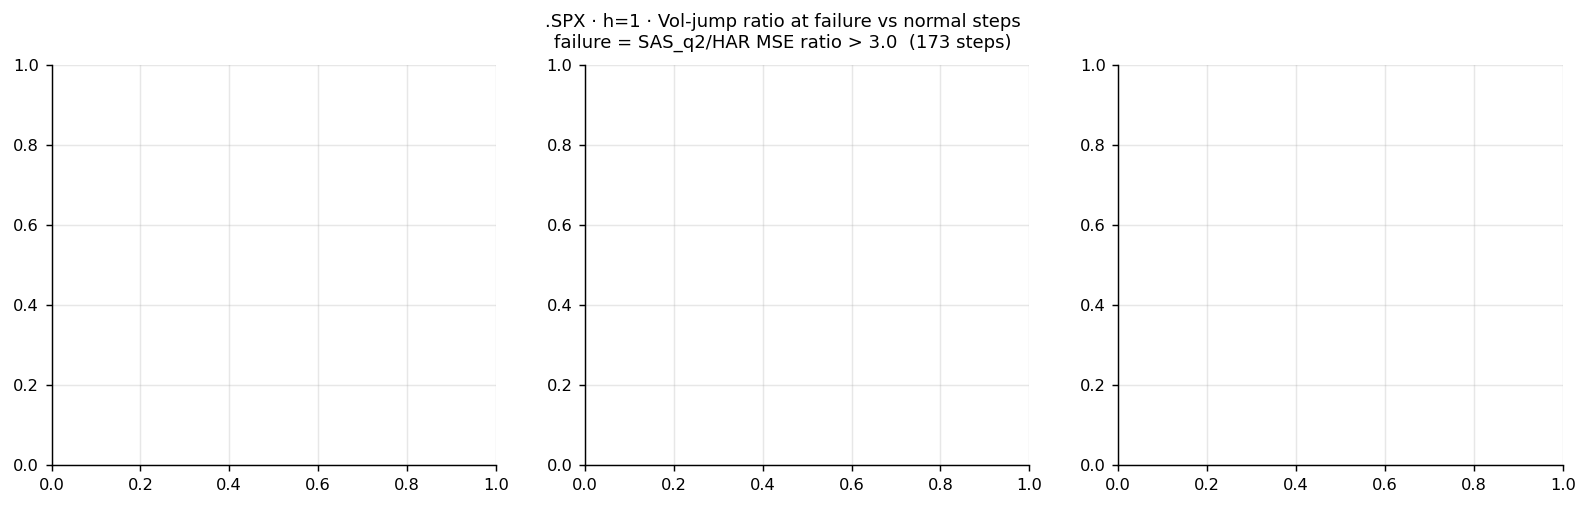

In [43]:
JUMP_LOOKBACK = 20

# Rolling median of true RV over the past JUMP_LOOKBACK steps
roll_med = pd.Series(y_true, index=dates).shift(1).rolling(
    JUMP_LOOKBACK, min_periods=JUMP_LOOKBACK // 2
).median()

vol_jump = y_true / roll_med.clip(lower=1e-20).values   # ratio > 1 → vol jumped up

# "failure" steps: challenger MSE > 3× benchmark MSE at that step
mse_ratio_step = sq_chal / np.clip(sq_bench, 1e-30, None)
FAIL_THRESH    = 3.0
is_failure     = mse_ratio_step > FAIL_THRESH
is_normal      = mse_ratio_step < 1.0   # challenger strictly better

jump_fail   = vol_jump[is_failure & np.isfinite(vol_jump)]
jump_normal = vol_jump[is_normal  & np.isfinite(vol_jump)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    f"{SYMBOL} · h={H} · Vol-jump ratio at failure vs normal steps\n"
    f"failure = {CHALLENGER}/HAR MSE ratio > {FAIL_THRESH}  ({is_failure.sum()} steps)",
    fontsize=10
)

# ── histogram of vol-jump ratio ──
ax = axes[0]
bins = np.linspace(0, min(np.nanpercentile(vol_jump, 99), 20), 40)
ax.hist(np.clip(jump_normal, 0, bins[-1]), bins=bins, color=C_BENCH, alpha=0.6,
        density=True, label=f'{CHALLENGER} better ({is_normal.sum()})')
ax.hist(np.clip(jump_fail, 0, bins[-1]),   bins=bins, color=C_CHAL,  alpha=0.6,
        density=True, label=f'{CHALLENGER} fails ({is_failure.sum()})')
ax.axvline(1.0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Vol jump ratio (RV_t / median RV_{t-20:t-1})')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.set_title('Distribution of vol-jump ratio')

# ── scatter: vol_jump vs mse_ratio_step ──
ax = axes[1]
finite = np.isfinite(vol_jump) & np.isfinite(mse_ratio_step)
sc = ax.scatter(
    np.clip(vol_jump[finite], 0, np.nanpercentile(vol_jump[finite], 99)),
    np.clip(mse_ratio_step[finite], 0, np.nanpercentile(mse_ratio_step[finite], 99)),
    c=np.log1p(sq_bench[finite]),
    cmap='viridis', alpha=0.25, s=4, rasterized=True
)
ax.axhline(1.0, color='gray', ls='--', lw=0.8)
ax.axvline(1.0, color='gray', ls='--', lw=0.8)
plt.colorbar(sc, ax=ax, label='log(1+HAR sq_err)')
ax.set_xlabel('Vol jump ratio')
ax.set_ylabel(f'{CHALLENGER}/HAR MSE ratio (step-level)')
ax.set_title('MSE ratio vs vol jump')

# ── box plot ──
ax = axes[2]
# Bin vol-jump into quartiles, compute median MSE ratio per bin
vj_s = pd.Series(vol_jump, index=dates)
mr_s = pd.Series(mse_ratio_step, index=dates)
finite_idx = vj_s.dropna().index.intersection(mr_s.dropna().index)
vj_f, mr_f = vj_s[finite_idx], mr_s[finite_idx]
quartiles  = pd.qcut(vj_f, 4, labels=['Q1\n(low jump)', 'Q2', 'Q3', 'Q4\n(high jump)'])
groups     = [mr_f[quartiles == q].clip(upper=np.nanpercentile(mr_f, 95)).values
              for q in quartiles.cat.categories]
bp = ax.boxplot(groups, patch_artist=True, medianprops=dict(color='red', lw=1.5),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], ['#a8d8ea', '#90be6d', '#f9c74f', '#f94144']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(1.0, color='gray', ls='--', lw=0.8)
ax.set_xticklabels(quartiles.cat.categories, fontsize=8)
ax.set_ylabel(f'{CHALLENGER}/HAR MSE ratio')
ax.set_title('MSE ratio by vol-jump quartile')

plt.tight_layout()
plt.savefig('vol_transition.png', bbox_inches='tight')
plt.show()

print(f"\nMedian vol-jump ratio — failure steps : {np.nanmedian(jump_fail):.3f}")
print(f"Median vol-jump ratio — normal  steps : {np.nanmedian(jump_normal):.3f}")
print("\n→ If failure median >> normal median, SAS fails specifically at vol jumps.")

## 6 · Calibration Scatter

Plot **predicted vs true RV** for both models.  
Points are coloured by who wins at that step (blue = benchmark better, red = challenger better, grey = similar).  
Underforecasting (ŷ << y) causes large QLIKE; overforecasting (ŷ >> y) costs only squared error.

In [ ]:
_qlike_label = "log-space QLIKE" if LOG else "QLIKE"

# Classify each step
SIMILAR_BAND = 1.2   # ratio within [1/1.2, 1.2] → 'similar'
ratio_step = np.where(sq_bench > 1e-30, sq_chal / sq_bench, np.nan)
color_step = np.where(ratio_step > SIMILAR_BAND, 'tomato',
             np.where(ratio_step < 1/SIMILAR_BAND, 'steelblue', 'lightgray'))

lim_max = np.nanpercentile(np.concatenate([y_true, y_bench, y_chal]), 99.5)
lim_min = np.nanpercentile(np.concatenate([y_true, y_bench, y_chal]), 0.5) if LOG else 0

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(f"{SYMBOL} · h={H} · Predicted vs True RV calibration scatter", fontsize=11)

patch_bench = mpatches.Patch(color='steelblue', alpha=0.6, label=f'{BENCH} wins')
patch_chal  = mpatches.Patch(color='tomato',    alpha=0.6, label=f'{CHALLENGER} wins')
patch_tie   = mpatches.Patch(color='lightgray', alpha=0.6, label='similar')

for ax, y_pred, label in [
    (axes[0], y_bench, BENCH),
    (axes[1], y_chal,  CHALLENGER),
]:
    ax.scatter(y_true, y_pred, c=color_step, s=4, alpha=0.4, rasterized=True)
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color='black', lw=0.8, ls='--', label='Perfect forecast')
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_xlabel('log-RV' if LOG else 'True RV')
    ax.set_ylabel('Predicted log-RV' if LOG else 'Predicted RV')
    ax.set_title(label)
    ax.set_aspect('equal')
    ax.legend(handles=[patch_bench, patch_chal, patch_tie], fontsize=7, loc='upper left')

    # Annotate under- and over-forecast regions
    ax.fill_between([lim_min, lim_max], [lim_min, lim_max], lim_min,
                    color='lightyellow', alpha=0.4, zorder=0)
    ax.text(0.97, 0.03, f'ŷ < y\n({_qlike_label}↑)', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=7, color='saddlebrown')
    ax.text(0.03, 0.97, 'ŷ > y\n(sq_err↑)', transform=ax.transAxes,
            ha='left', va='top', fontsize=7, color='navy')

plt.tight_layout()
plt.savefig('calibration_scatter.png', bbox_inches='tight')
plt.show()

# Summary stats
under_bench = np.mean(y_bench < y_true)
under_chal  = np.mean(y_chal  < y_true)
print(f"Fraction underforecasting (ŷ < y_true):  {BENCH}={under_bench:.1%}   {CHALLENGER}={under_chal:.1%}")
print(f"→ Higher underforecast rate drives higher {_qlike_label}.")

## 7 · Summary Table — Failure Mode Breakdown

Decompose OOS steps into four regimes and compute mean QLIKE and MSE ratio per regime.

In [ ]:
_qlike_label = "log-space QLIKE" if LOG else "QLIKE"

RV_MEDIAN   = np.nanmedian(y_true)
JUMP_THRESH = 2.0   # vol_jump > 2.0 → 'spike day'

vol_jump_finite = np.where(np.isfinite(vol_jump), vol_jump, 1.0)

regimes = {
    'low-vol, stable':   (y_true <= RV_MEDIAN) & (vol_jump_finite <= JUMP_THRESH),
    'low-vol, jumping':  (y_true <= RV_MEDIAN) & (vol_jump_finite >  JUMP_THRESH),
    'high-vol, stable':  (y_true >  RV_MEDIAN) & (vol_jump_finite <= JUMP_THRESH),
    'high-vol, jumping': (y_true >  RV_MEDIAN) & (vol_jump_finite >  JUMP_THRESH),
}

rows = []
for name, mask in regimes.items():
    m = mask & np.isfinite(ql_bench) & np.isfinite(ql_chal)
    if m.sum() == 0:
        continue
    row = {
        'Regime':    name,
        'N steps':   m.sum(),
        'MSE ratio': np.nanmean(sq_chal[m]) / max(np.nanmean(sq_bench[m]), 1e-30),
        f'{BENCH} {_qlike_label}':      np.nanmean(ql_bench[m]),
        f'{CHALLENGER} {_qlike_label}': np.nanmean(ql_chal[m]),
        'QLIKE ratio': (np.nanmean(ql_chal[m]) / max(np.nanmean(ql_bench[m]), 1e-10)),
    }
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index('Regime')

fmt = {
    'MSE ratio':                     '{:.2f}',
    f'{BENCH} {_qlike_label}':       '{:.4f}',
    f'{CHALLENGER} {_qlike_label}':  '{:.4f}',
    'QLIKE ratio':                   '{:.2f}',
}
grad_cols = ['MSE ratio', 'QLIKE ratio']

caption = (f'{CHALLENGER} vs {BENCH} — mean losses by vol regime  '
           f'[{"log-space " if LOG else ""}QLIKE & MSE ratio: >1 means challenger is worse]')

display(df_summary.style
    .format(fmt)
    .background_gradient(subset=grad_cols, cmap='RdYlGn_r', vmin=0.5, vmax=3)
    .set_caption(caption)
)